In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/flights_prepared_final.csv")

In [3]:
df["FlightDate"] = pd.to_datetime(df["FlightDate"])
# échantillon pour que les graphes soient rapides
d = df.sample(min(len(df), 1_000_000), random_state=42).copy()
print(df.shape)
df.describe().T

(7917259, 26)


,count,mean,min,25%,50%,75%,max,std
FlightDate,7917259,2019-07-04 02:36:01.374384,2019-01-01 00:00:00,2019-04-06 00:00:00,2019-07-05 00:00:00,2019-10-02 00:00:00,2019-12-31 00:00:00,NaN
CRSDepTime,7917259.0,1328.992739,1.0,915.0,1320.0,1735.0,2359.0,490.427576
CRSElapsedTime,7917259.0,138.492937,17.0,88.0,120.0,168.0,813.0,71.292158
Distance,7917259.0,770.491676,31.0,345.0,606.0,1005.0,5095.0,584.613513
Year,7917259.0,2019.0,2019.0,2019.0,2019.0,2019.0,2019.0,0.0
Quarter,7917259.0,2.531314,1.0,2.0,3.0,4.0,4.0,1.106413
Month,7917259.0,6.59604,1.0,4.0,7.0,10.0,12.0,3.402802
DayofMonth,7917259.0,15.717666,1.0,8.0,16.0,23.0,31.0,8.760826
DayOfWeek,7917259.0,3.939725,1.0,2.0,4.0,6.0,7.0,1.995702
Flight_Number_Marketing_Airline,7917259.0,2703.877102,1.0,1116.0,2306.0,4195.0,9401.0,1835.071693


In [5]:
TARGET = "ArrDel15"
print(df[TARGET].value_counts(normalize=True))
df[TARGET].value_counts().plot(kind="bar", title="Distribution de ArrDel15 (0 = à l'heure, 1 = retard > 15 min)")
plt.show()


ArrDel15
0.0    0.807073
1.0    0.192927
Name: proportion, dtype: float64


<Figure size 640x480 with 1 Axes>

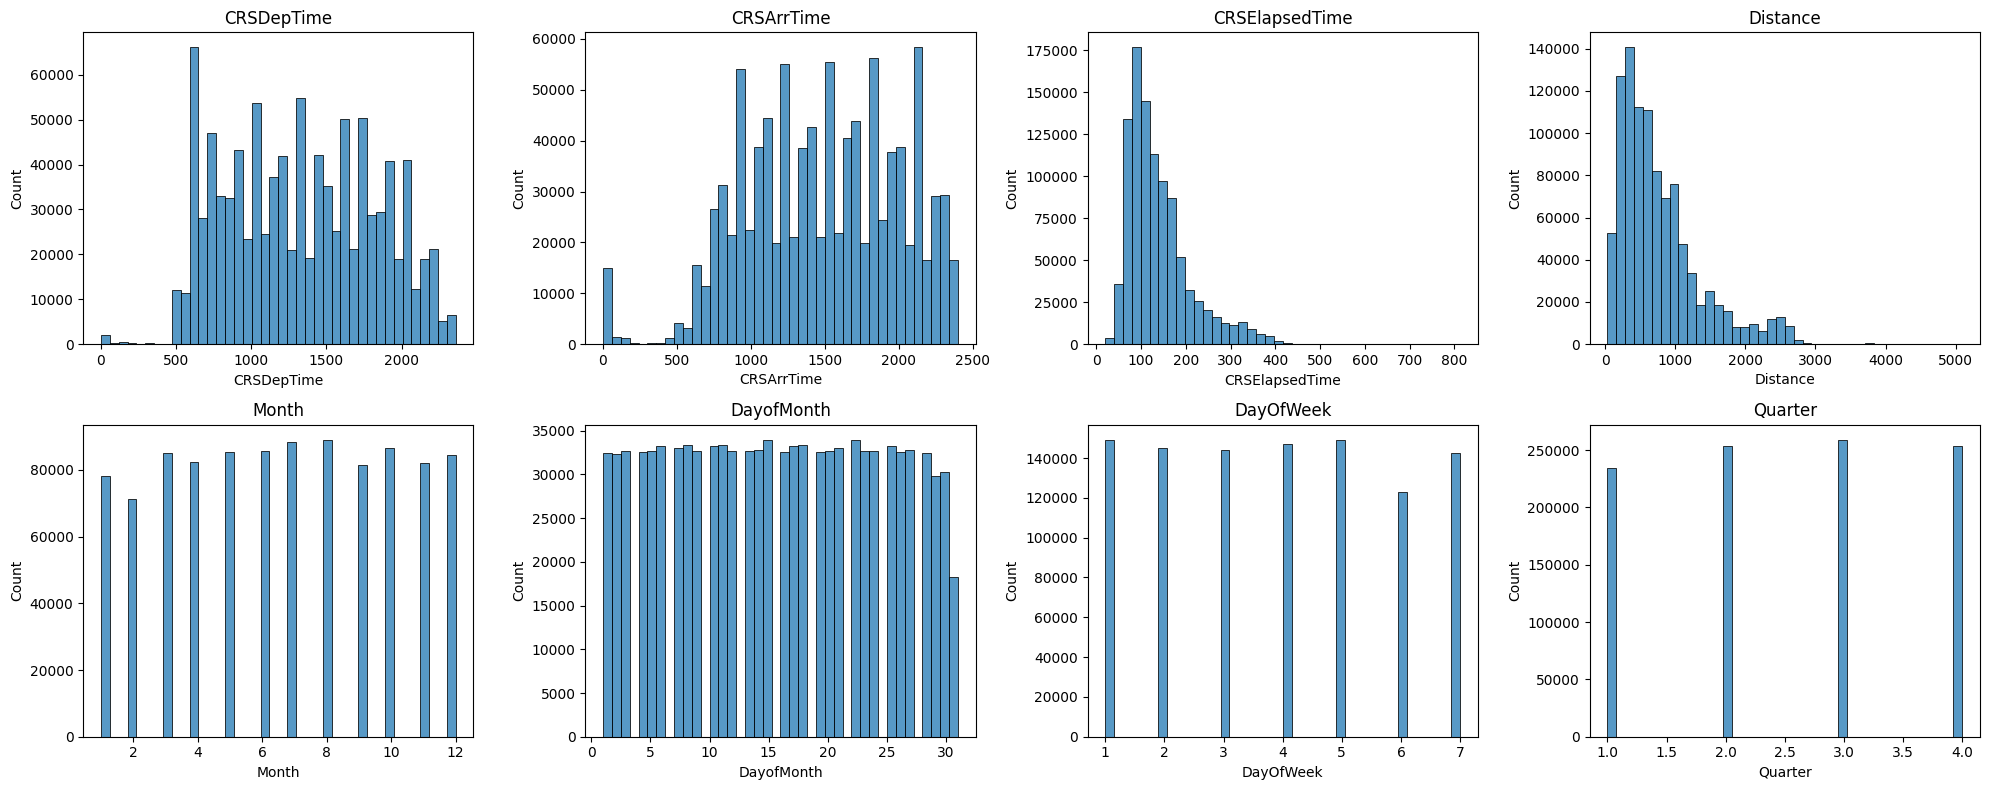

In [6]:
# 2. Histogrammes des variables numériques
num_cols = ["CRSDepTime", "CRSArrTime", "CRSElapsedTime", "Distance",
            "Month", "DayofMonth", "DayOfWeek", "Quarter"]
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for ax, c in zip(axes.ravel(), num_cols):
    sns.histplot(d[c], bins=40, ax=ax)
    ax.set_title(c)
plt.tight_layout(); plt.show()

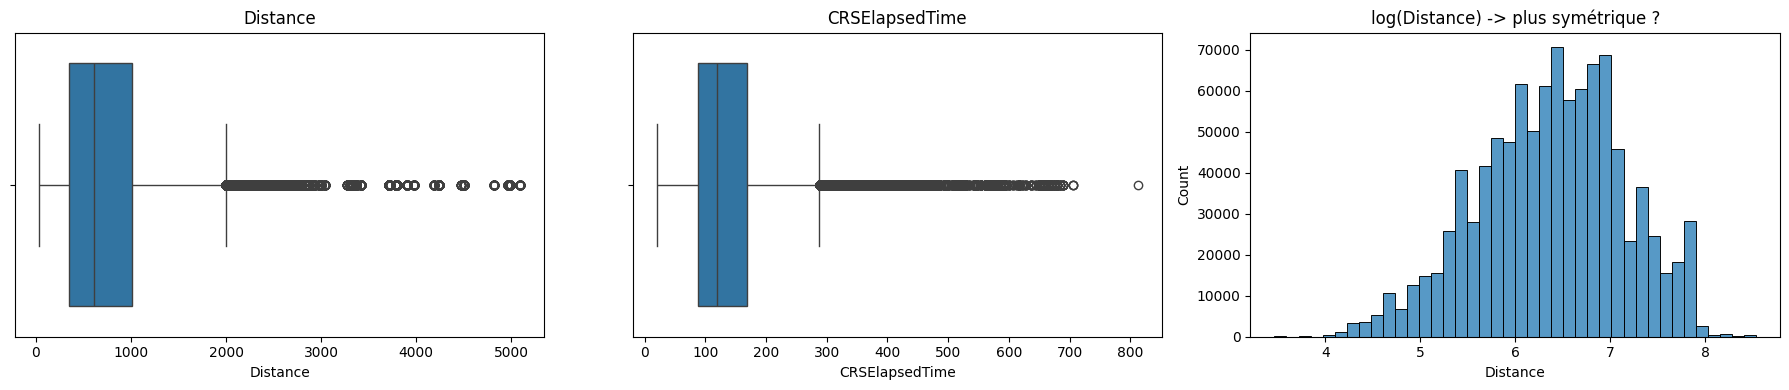

       Distance  CRSElapsedTime
0.010      89.0            47.0
0.500     606.0           120.0
0.900    1587.0           236.0
0.990    2586.0           373.0
0.999    3724.0           456.0


In [7]:
# 3. Distributions extrêmes (outliers) : boxplots + log
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.boxplot(x=d["Distance"], ax=axes[0]); axes[0].set_title("Distance")
sns.boxplot(x=d["CRSElapsedTime"], ax=axes[1]); axes[1].set_title("CRSElapsedTime")
sns.histplot(np.log1p(d["Distance"]), bins=40, ax=axes[2]); axes[2].set_title("log(Distance) -> plus symétrique ?")
plt.tight_layout(); plt.show()
 
print(d[["Distance", "CRSElapsedTime"]].quantile([.01, .5, .9, .99, .999]))

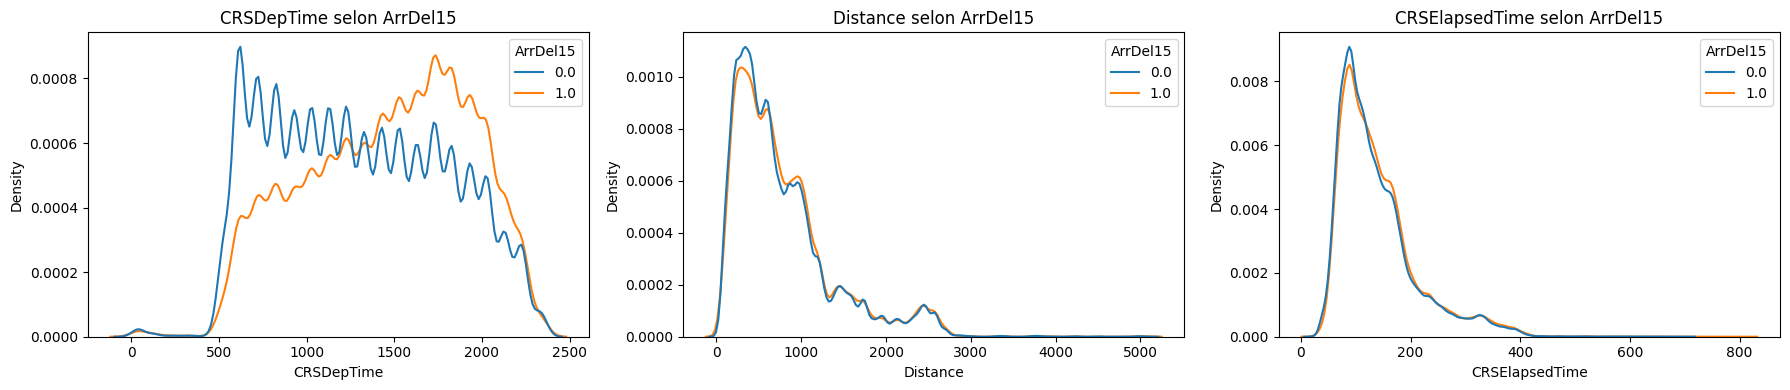

In [8]:
# 4. Distributions selon la cible (retard vs pas retard)
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, c in zip(axes, ["CRSDepTime", "Distance", "CRSElapsedTime"]):
    sns.kdeplot(data=d, x=c, hue=TARGET, common_norm=False, ax=ax)
    ax.set_title(f"{c} selon ArrDel15")
plt.tight_layout(); plt.show()

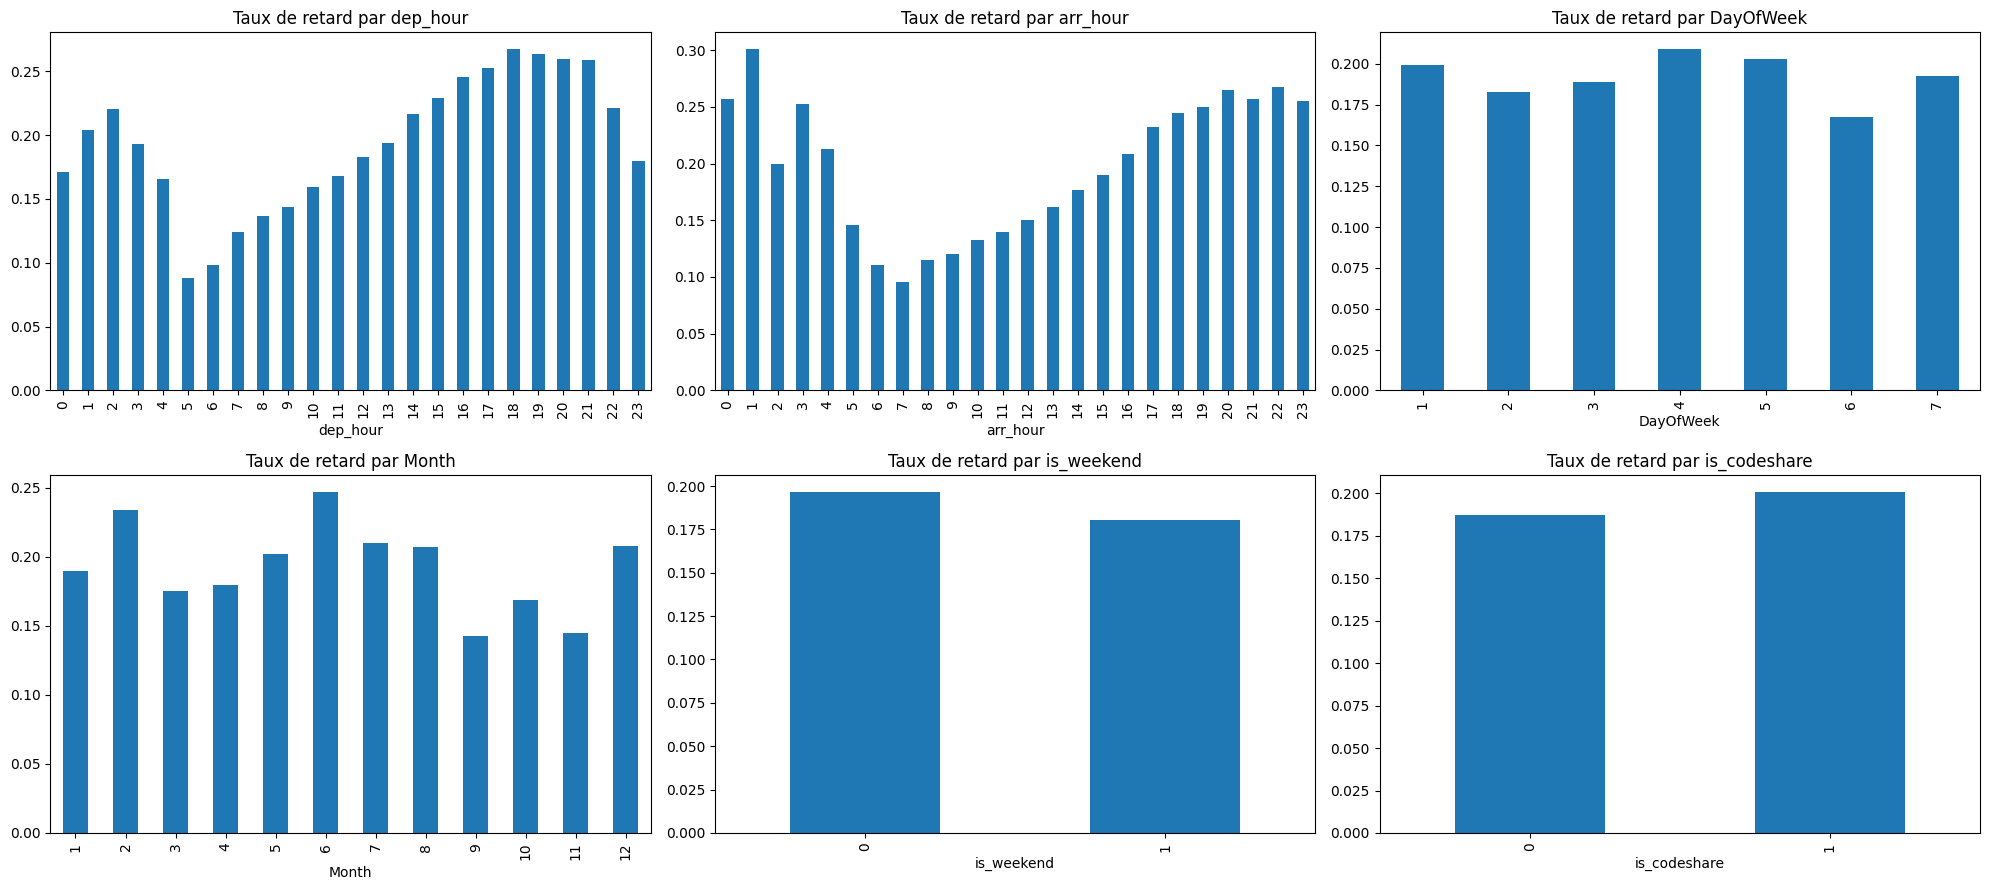

In [9]:
# 5. Taux de retard par catégorie (idées de features)
 

d["dep_hour"] = (d["CRSDepTime"] // 100).clip(upper=23)
d["arr_hour"] = (d["CRSArrTime"] // 100).clip(upper=23)
 
fig, axes = plt.subplots(2, 3, figsize=(20, 9))
for ax, c in zip(axes.ravel(), ["dep_hour", "arr_hour", "DayOfWeek", "Month", "is_weekend", "is_codeshare"]):
    d.groupby(c)[TARGET].mean().plot(kind="bar", ax=ax, title=f"Taux de retard par {c}")
plt.tight_layout(); plt.show()

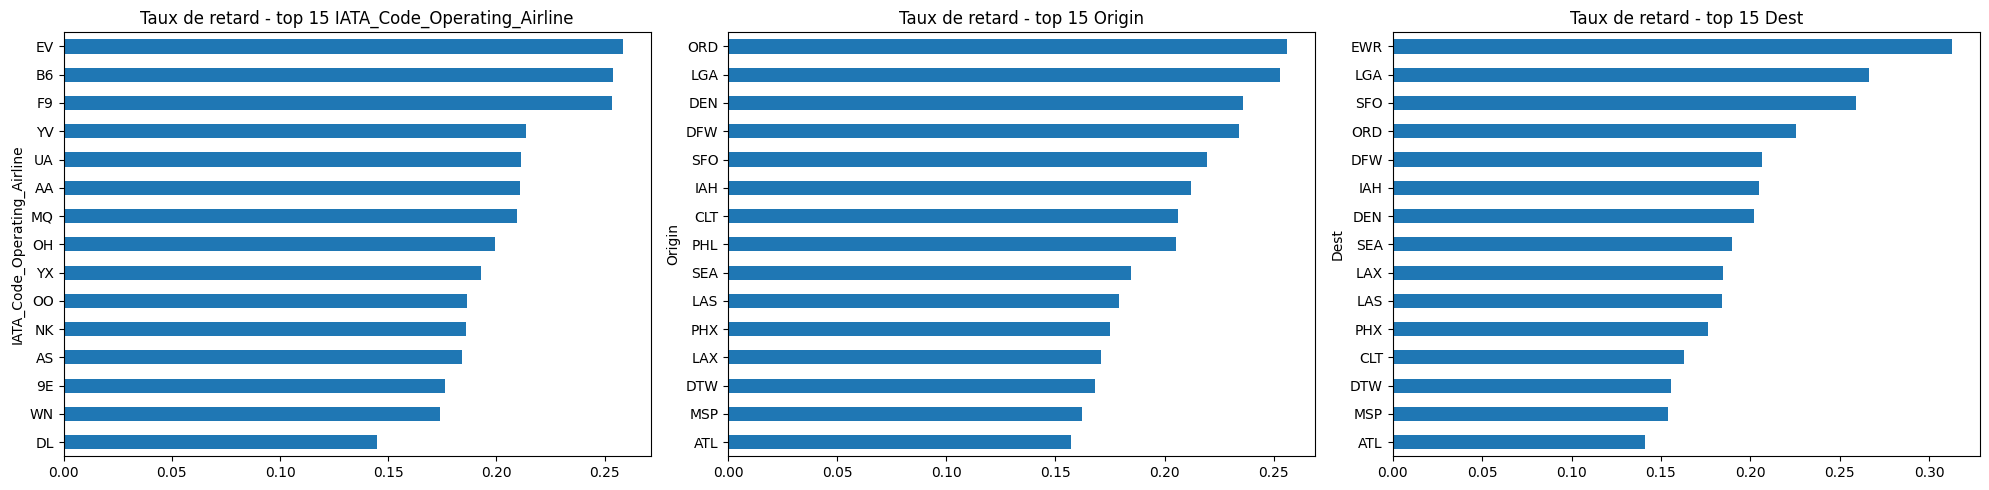

In [10]:
# compagnies et aéroports (top 15 par volume)
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, c in zip(axes, ["IATA_Code_Operating_Airline", "Origin", "Dest"]):
    g = d.groupby(c)[TARGET].agg(["mean", "size"])
    g = g.sort_values("size", ascending=False).head(15).sort_values("mean")
    g["mean"].plot(kind="barh", ax=ax, title=f"Taux de retard - top 15 {c}")
plt.tight_layout(); plt.show()

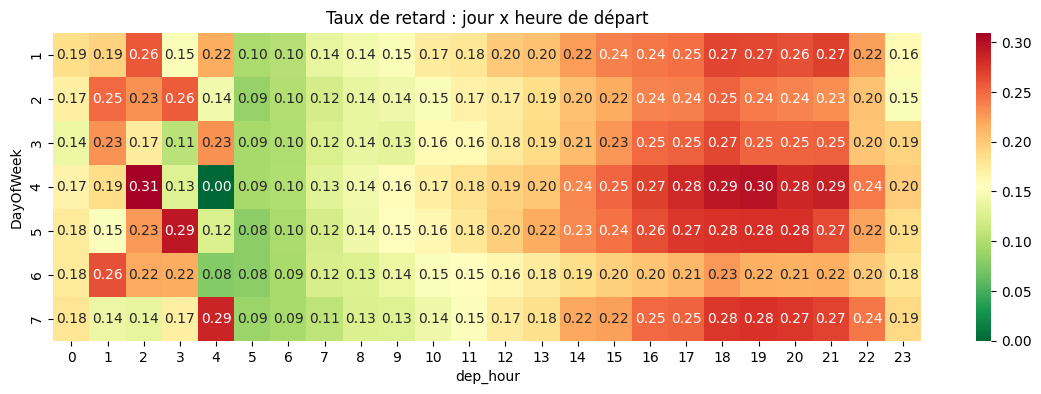

In [11]:
# 6. Heatmap jour x heure
 
pv = d.pivot_table(index="DayOfWeek", columns="dep_hour", values=TARGET, aggfunc="mean")
plt.figure(figsize=(14, 4))
sns.heatmap(pv, cmap="RdYlGn_r", annot=True, fmt=".2f")
plt.title("Taux de retard : jour x heure de départ"); plt.show()

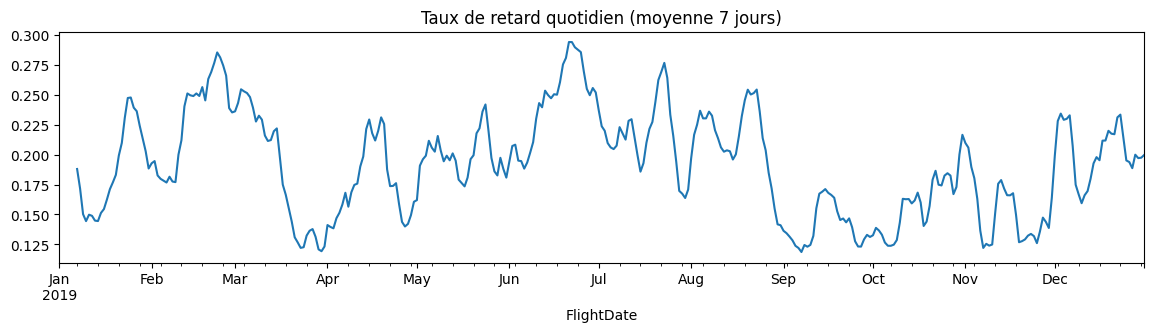

In [12]:
# 7. Tendance dans le temps
 
daily = df.groupby("FlightDate")[TARGET].mean()
daily.rolling(7).mean().plot(figsize=(14, 3), title="Taux de retard quotidien (moyenne 7 jours)")
plt.show()
 

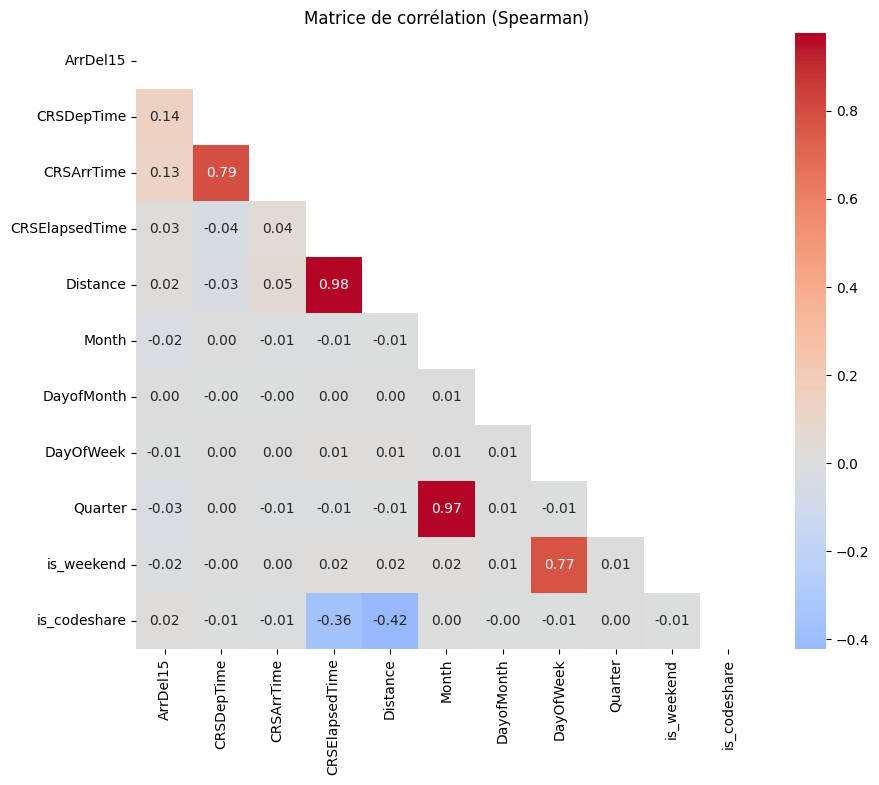

CRSDepTime        0.135574
CRSArrTime        0.128996
Quarter          -0.027061
CRSElapsedTime    0.025747
Month            -0.024807
Distance          0.020028
is_weekend       -0.017791
is_codeshare      0.016595
DayOfWeek        -0.005352
DayofMonth        0.001766
Name: ArrDel15, dtype: float64


In [13]:
# 8. Matrice de corrélation
# On exclut les colonnes *_encoded (l'ordre du label encoding est arbitraire).
 
corr_cols = [TARGET, "CRSDepTime", "CRSArrTime", "CRSElapsedTime", "Distance",
             "Month", "DayofMonth", "DayOfWeek", "Quarter", "is_weekend", "is_codeshare"]
corr = d[corr_cols].corr(method="spearman")
 
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, mask=np.triu(np.ones_like(corr, dtype=bool)))
plt.title("Matrice de corrélation (Spearman)"); plt.show()
 
print(corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False))